# Module 02: A Box Model of Land-Atmosphere Carbon Balance

### 1. Introduction


In [16]:
import numpy as np
import matplotlib.pyplot as plt

M1i = 1066.66
M2i = 333.33

k12 = 0.0003 
k21 = 0.1

ti = 0.0
tf = 100.0
dt = 1


In [3]:
t = np.arange(ti,tf+dt,dt)

Nt = t.size

print('t has '+str(Nt)+' time steps')

t has 36501 time steps


In [4]:
M1 = np.zeros((Nt,)) #creates empty space for our model to fill 
M2 = np.zeros((Nt,))

In [5]:
for i in np.arange(Nt):
    if (i==0):

        M1[i] = M1i #setting initial land and atmospheric carbon mass values for first time step
        M2[i] = M2i
        
    else:
        dM1dt = k21*M2[i-1] - k12*M1[i-1]*M2[i-1] #calculating the change in atmospheric carbon mass for each time step
        dM2dt = k12*M1[i-1]*M2[i-1] - k21*M2[i-1] #calculating the change in land carbon mass for each time step
        
        M1[i] = M1[i-1] + dM1dt*dt #subtracting the chnange in carbon mass from the previous time step to get the current mass of carbon 
        M2[i] = M2[i-1] + dM2dt*dt

print(M1)
print(M2)

[1100.         1099.8109589  1099.62184533 ...  333.33333333  333.33333333
  333.33333333]
[ 300.          300.1890411   300.37815467 ... 1066.66666667 1066.66666667
 1066.66666667]


In [66]:
M1_anlt = (k12*(M1i+M2i))/(k12+k21) + (k21*M1i - k12*M2i)/(k12+k21)*np.exp(-(k12+k21)*t) 
M2_anlt = (k21*(M1i+M2i))/(k12+k21) - (k21*M1i - k12*M2i)/(k12+k21)*np.exp(-(k12+k21)*t)

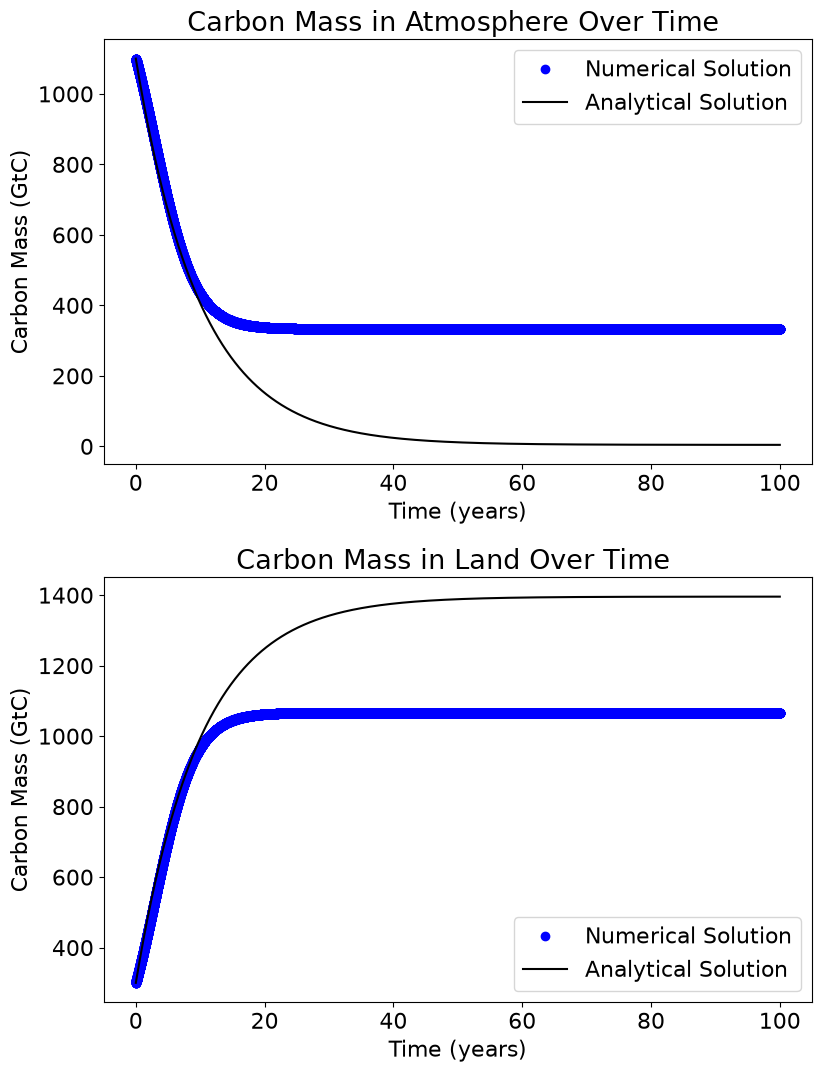

In [68]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time ')
plt.plot(t,M1,'bo', label='Numerical Solution')
plt.plot(t,M1_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()


plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time ')
plt.plot(t,M2,'bo', label='Numerical Solution')
plt.plot(t,M2_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()

plt.tight_layout() #added so plots don't overlap
plt.show()

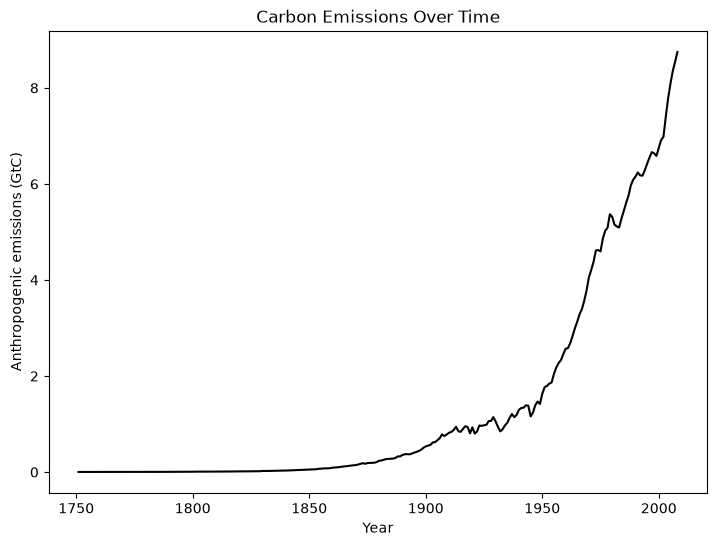

In [18]:
import pandas as pd
emissions = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/AnthropogenicEmissions.1751_2008.csv')

plt.figure(figsize=(8.5, 6))# Make the figure


plt.plot(emissions['Year'], emissions['Anthropogenic emissions (GtC)'], 'k-')

plt.xlabel('Year')
plt.ylabel('Anthropogenic emissions (GtC)')
plt.title('Carbon Emissions Over Time')

plt.show()

In [22]:
# New time array for the emissions-driven model
ti_em = 1751.0
tf_em = 2008.0
dt_em = 1

t_em = np.arange(ti_em, tf_em+dt_em, dt_em)
Nt_em = t_em.size
print('t_em has '+str(Nt_em)+' time steps')

#create empty arrays for new loop
M1_em = np.zeros(Nt_em)
M2_em = np.zeros(Nt_em)
dM1dt_arr = np.zeros(Nt_em) #stores change in each time step for the second figure 
dM2dt_arr = np.zeros(Nt_em)


emissions_df = pd.read_csv('/Users/kyleformigli/Downloads/Modelling_Class_Psets/Mod2/AnthropogenicEmissions.1751_2008.csv')
emissions = emissions_df['Anthropogenic emissions (GtC)'].values #define variable in emissions data
print('emissions has '+str(emissions.size)+' values')

for i in np.arange(Nt_em):
    if (i==0):
        M1_em[i] = M1i
        M2_em[i] = M2i
        # no rate of change exists yet at the very first time step
        
    else:
        dM1dt = k21*M2_em[i-1] - k12*M1_em[i-1]*M2_em[i-1] + emissions[i-1]
        dM2dt = k12*M1_em[i-1]*M2_em[i-1] - k21*M2_em[i-1]
        
        M1_em[i] = M1_em[i-1] + dM1dt*dt_em
        M2_em[i] = M2_em[i-1] + dM2dt*dt_em
        
        dM1dt_arr[i] = dM1dt  # save the rate of change for this step
        dM2dt_arr[i] = dM2dt

print(M1_em)
print(M2_em)

t_em has 258 time steps
emissions has 258 values
[1066.66        993.33106666  912.81528039  828.1245508   743.24001431
  662.47967659  589.65654761  527.34598092  476.55656568  436.88139807
  406.96514978  385.03202004  369.29290984  358.17649221  350.41462
  345.03897539  341.33715364  338.79805824  337.06123802  335.87542849
  335.06686087  334.51700759  334.14263298  333.8878395   333.71447946
  333.59654873  333.51633506  333.46178049  333.42467935  333.39944888
  333.38229151  333.37162429  333.36437053  333.35943799  333.35608388
  333.35380311  333.3522522   333.35119759  333.35048045  333.34999279
  333.34966118  333.35043566  333.35096225  333.35132029  333.35156371
  333.35172919  333.35184168  333.35291813  333.35365004  333.35414766
  333.35548597  333.35639591  333.35901457  333.35979506  333.36032567
  333.36068639  333.36193159  333.36277816  333.36335369  333.36374492
  333.36401085  333.36519156  333.36599426  333.36653993  333.36691083
  333.36816291  333.37001409  3

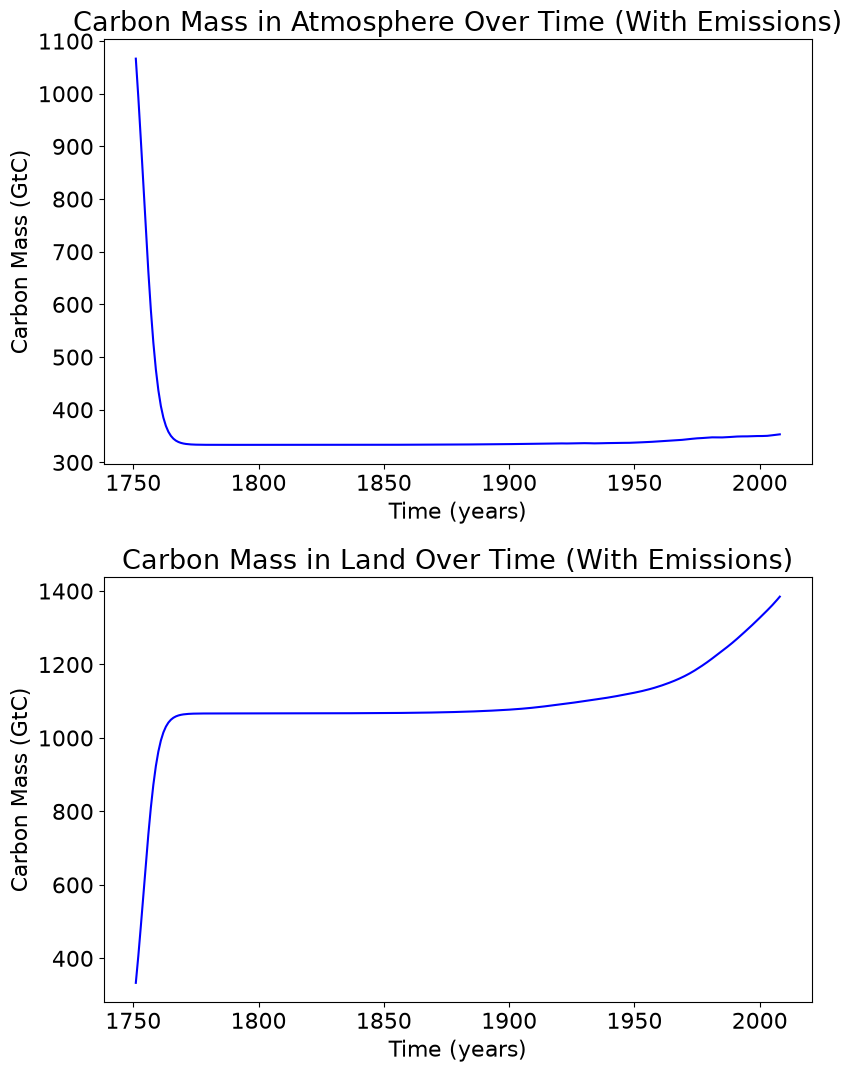

In [21]:
#Creating two pannel figure for mass in reservoirs with emissions
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time (With Emissions)')
plt.plot(t_em, M1_em, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')

plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time (With Emissions)')
plt.plot(t_em, M2_em, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')

plt.tight_layout()
plt.show()

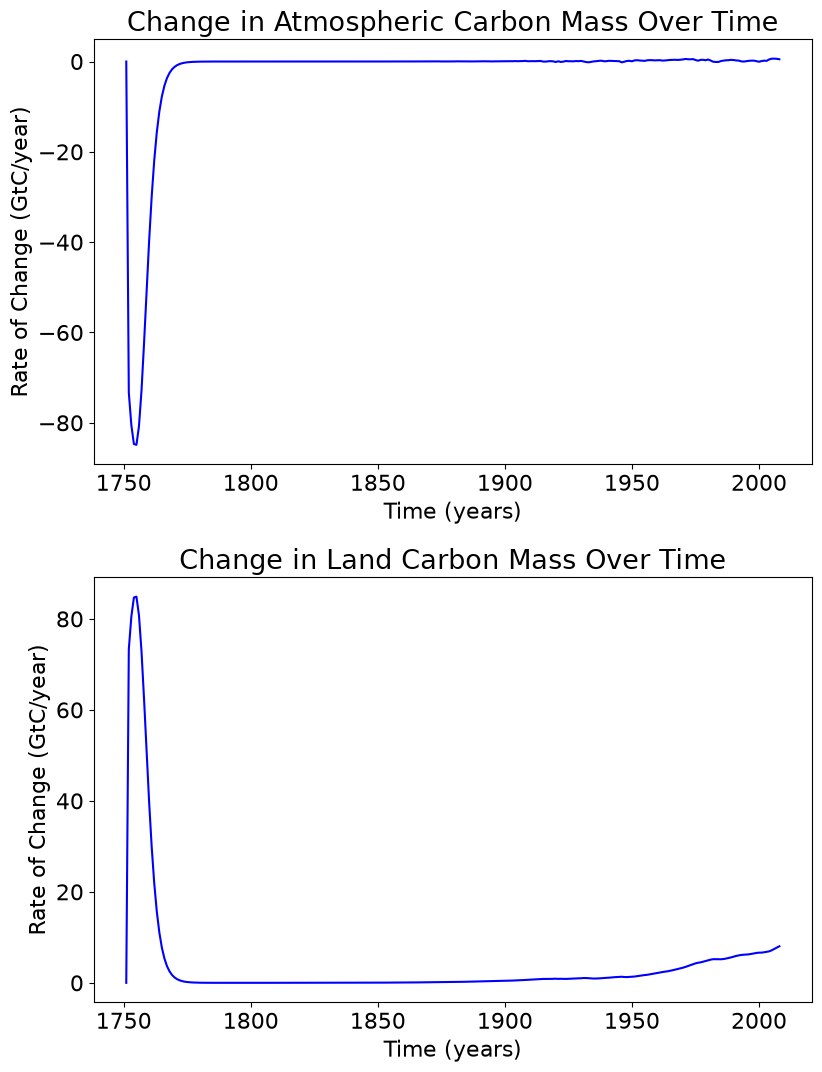

In [23]:
#create a two pannel figure for change in carbon in each reservoir over time 
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Change in Atmospheric Carbon Mass Over Time')
plt.plot(t_em, dM1dt_arr, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')

plt.subplot(2,1,2)
plt.title('Change in Land Carbon Mass Over Time')
plt.plot(t_em, dM2dt_arr, 'b-')
plt.xlabel('Time (years)')
plt.ylabel('Rate of Change (GtC/year)')

plt.tight_layout()
plt.show()